  ZPPA REGISTERED SUPPLIERS – EXPLORATORY DATA ANALYSIS

 Shape   : 59,423 rows x 11 columns
 Columns : ['company_name', 'tax_identification_number', 'physical_address', 'postalcode', 'town_city', 'phone', 'status', 'registration_date', 'registration_number', 'country_resource_key', 'company_type']

--- Status counts ---
status_clean
active         45015
pending        13489
deactivated      919
Name: count, dtype: int64

--- Company type counts ---
company_type_clean
local                   36722
business                19583
other                    1959
foreign                   799
individualconsultant      175
consortium                100
government.agency          74
Name: count, dtype: int64

--- Top countries ---
country_code
ZM    58643
ZA      228
IN       90
GB       57
CN       41
AE       34
US       28
KE       27
ZW       16
IT       15
Name: count, dtype: int64

--- Missing Values (%) ---
postalcode                   19.43
registration_date             0.09
reg_month  

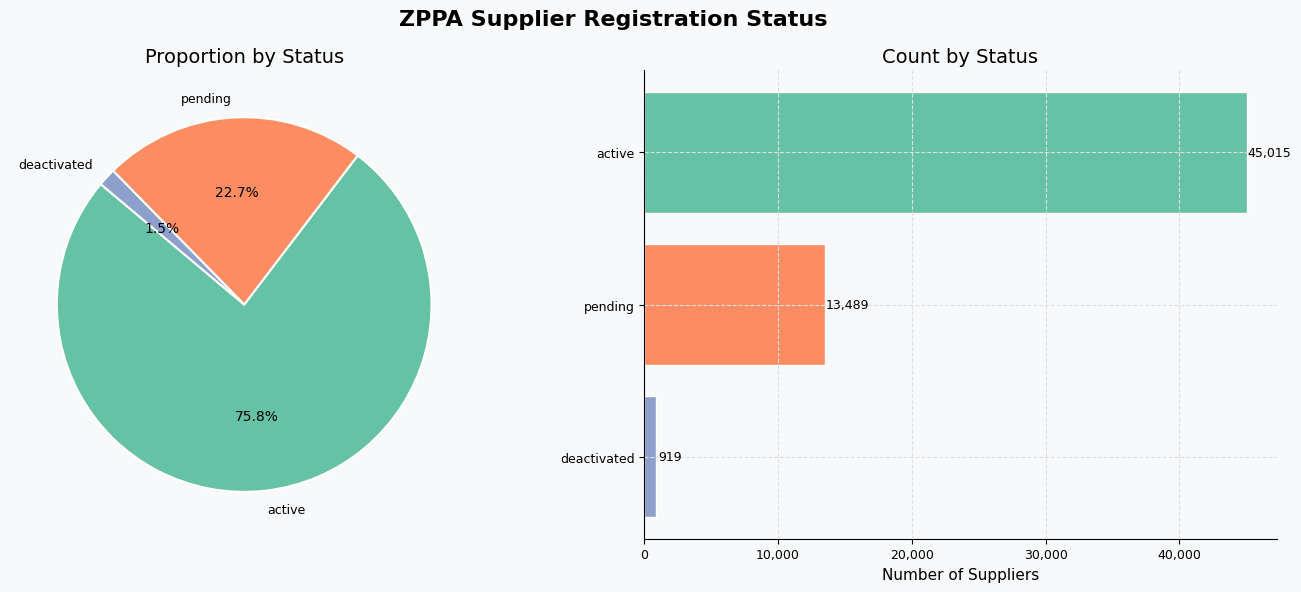

Figure 1 saved


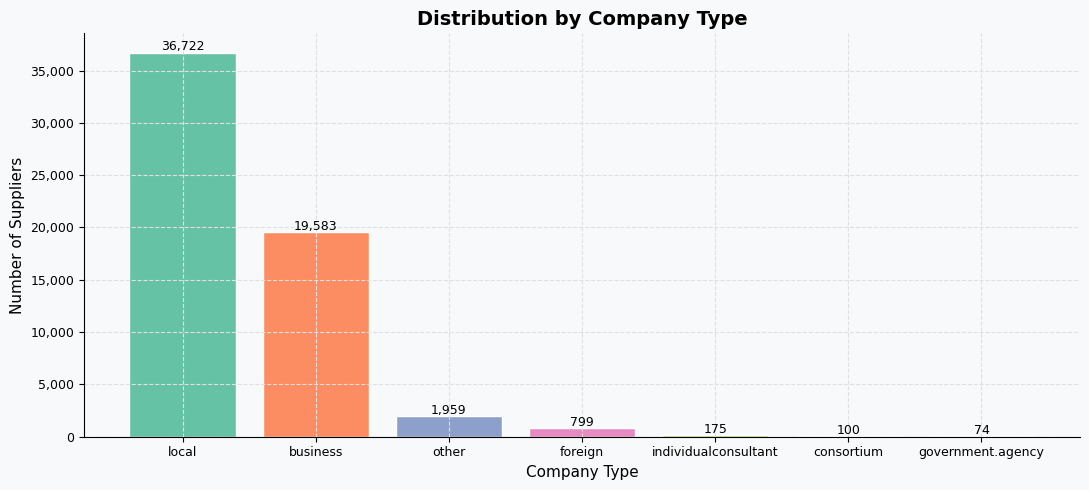

Figure 2 saved


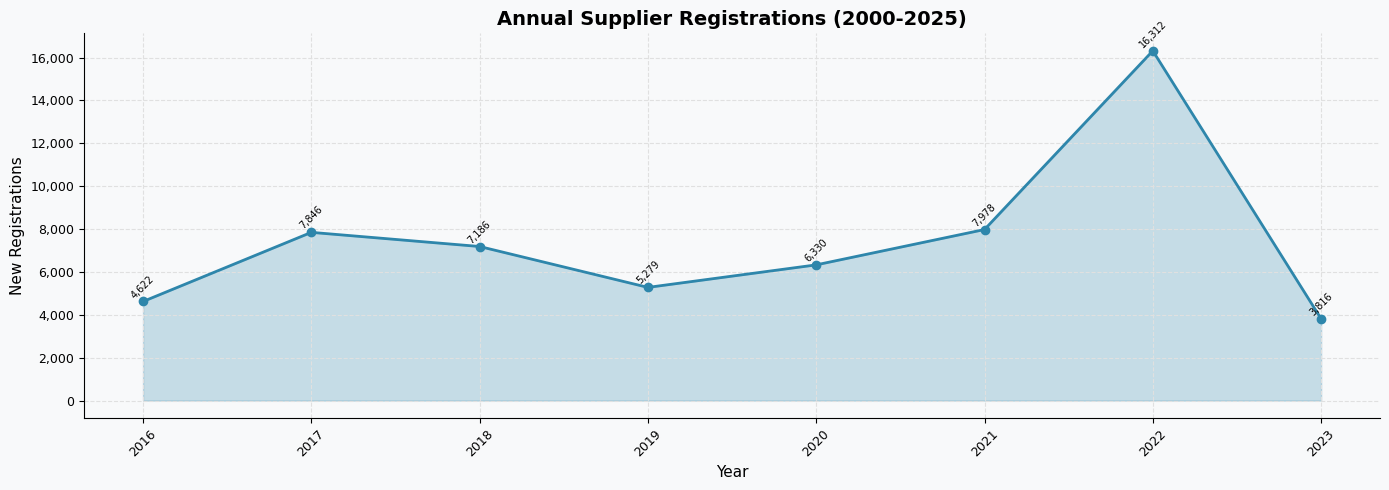

Figure 3 saved


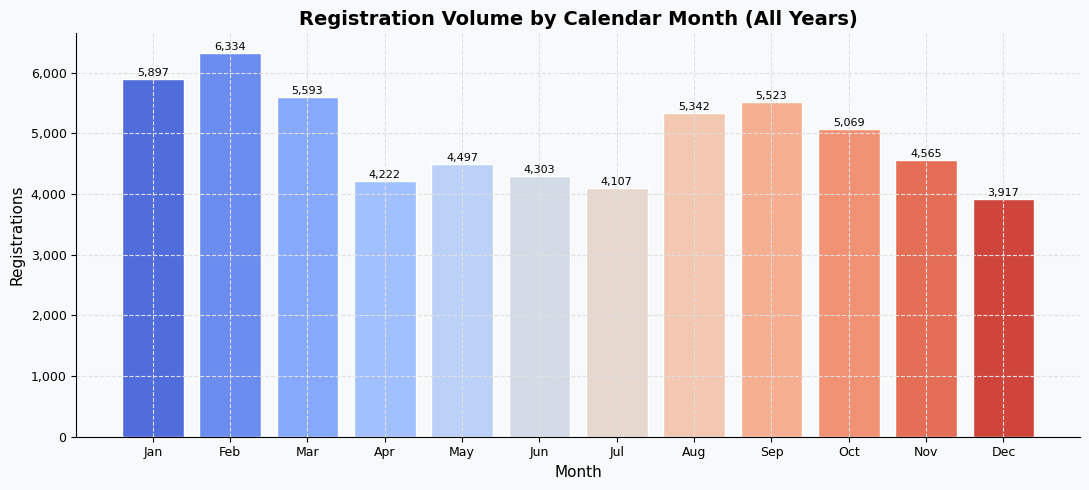

Figure 4 saved


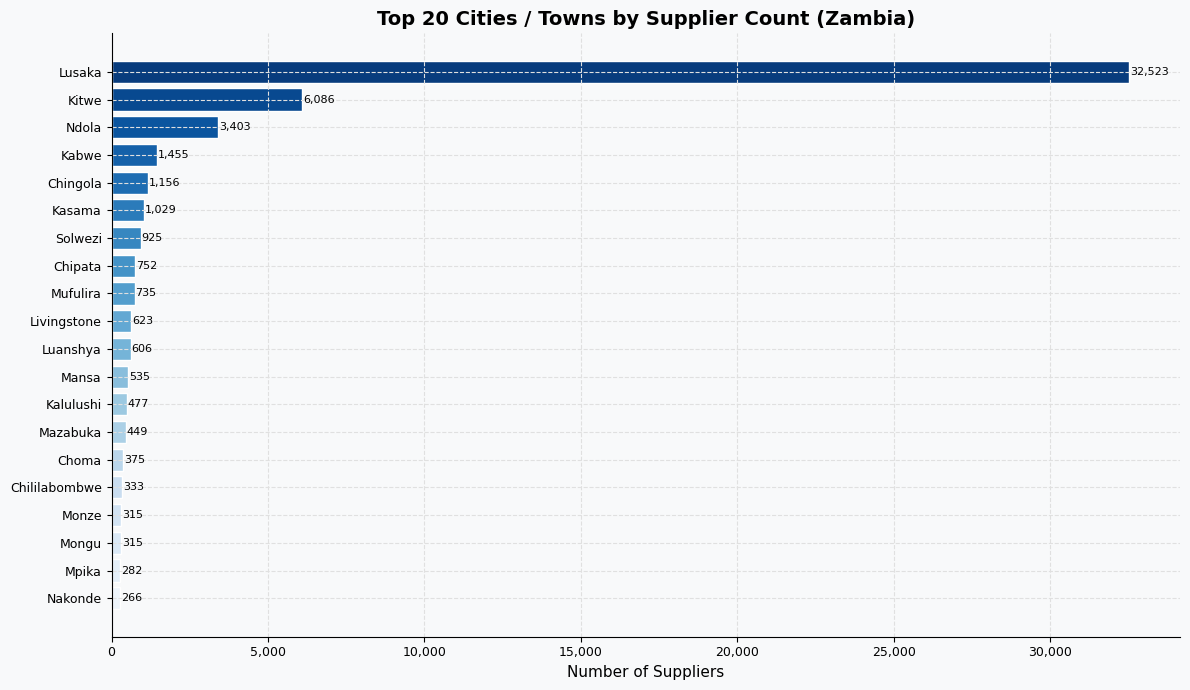

Figure 5 saved


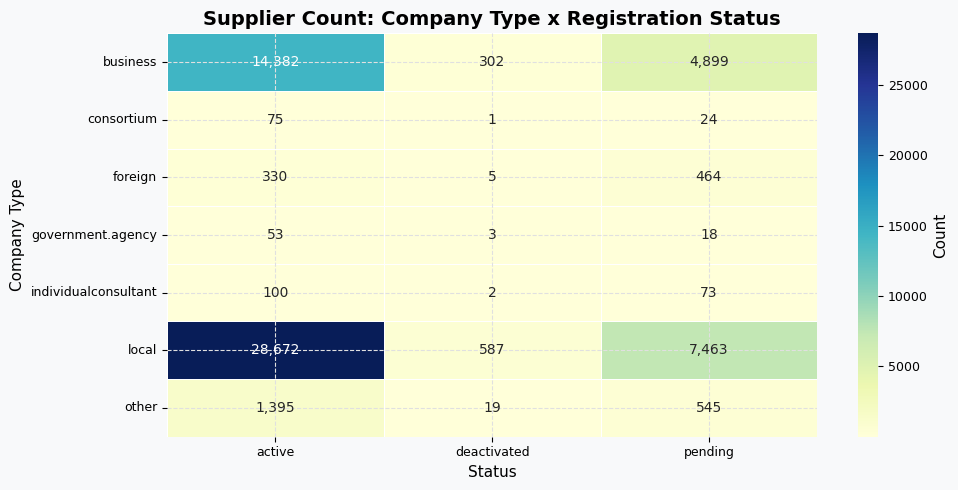

Figure 6 saved


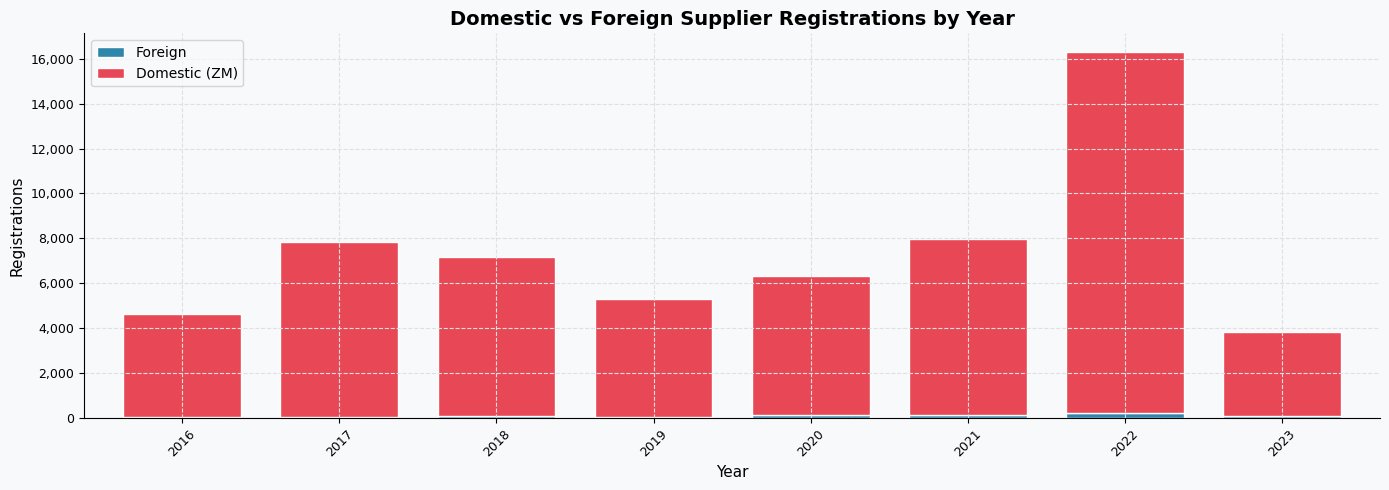

Figure 7 saved


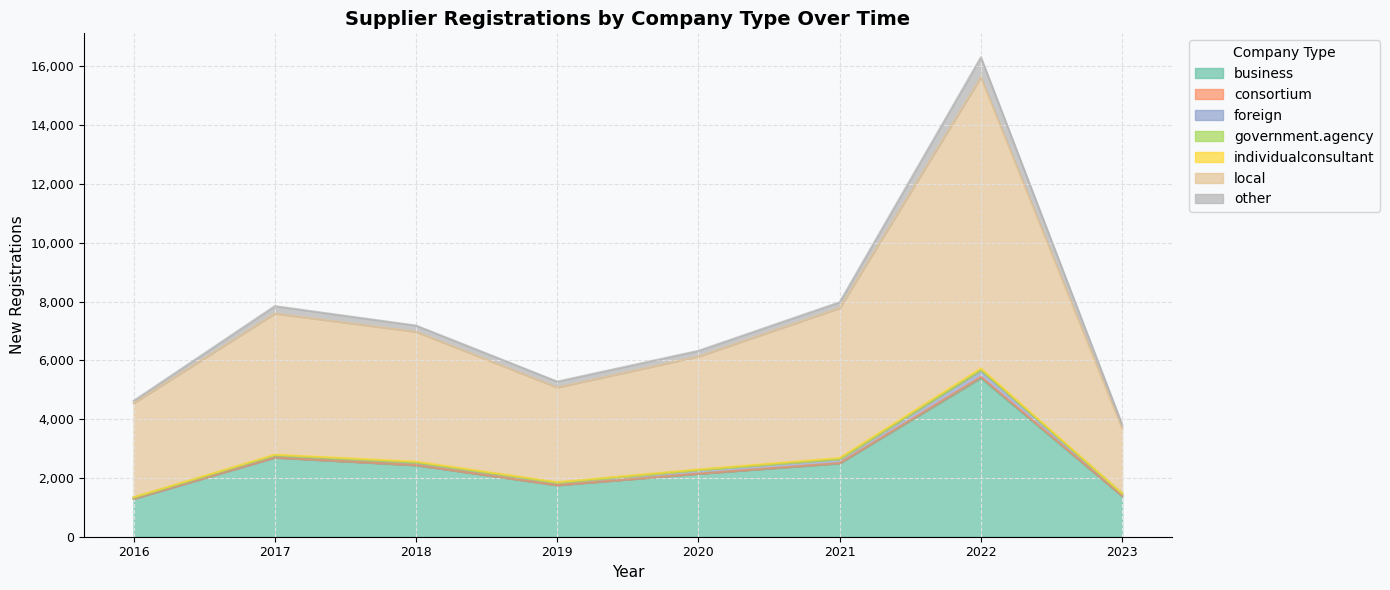

Figure 8 saved


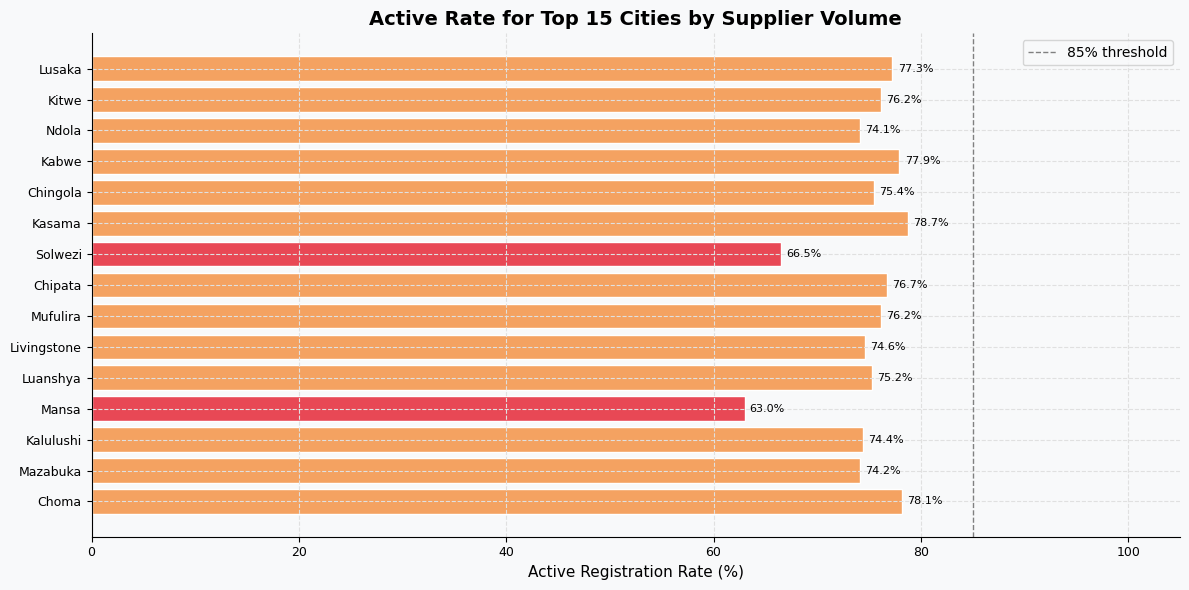

Figure 9 saved


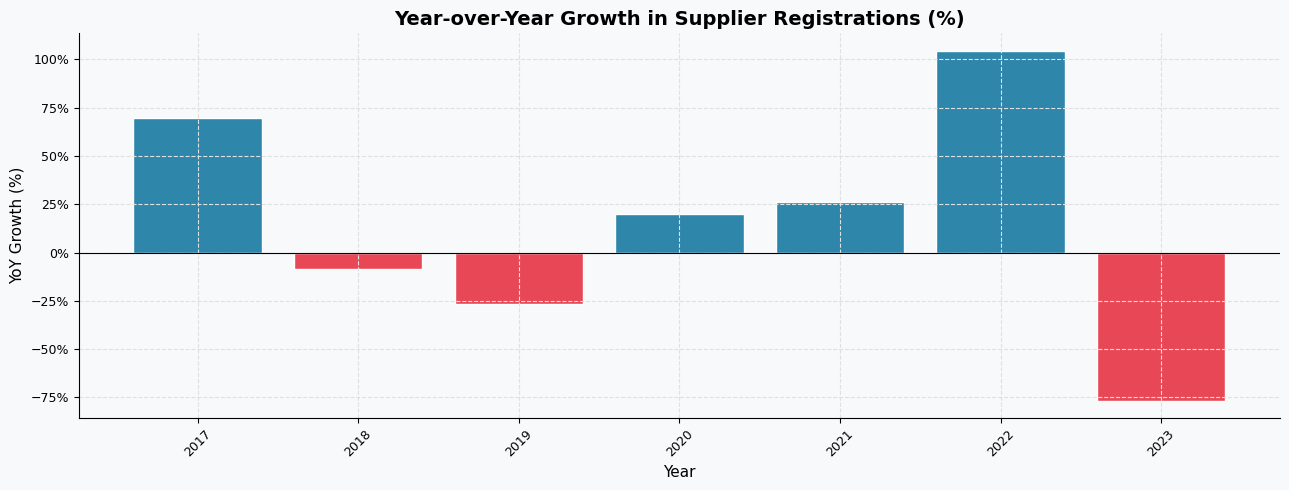

Figure 10 saved

  STATISTICAL ANALYSIS

Chi-Square Test: Company Type vs Status
   chi2 = 820.14,  df = 12,  p = 7.9253e-168
   -> Significant association (p<0.05)

Kruskal-Wallis: Registration Year across Company Types
   H = 111.42,  p = 1.0267e-21
   -> Significant difference (p<0.05)

Pearson Correlation: Year vs Annual Registrations
   r = 0.300,  p = 4.6985e-01
   -> No significant positive trend

  SUMMARY REPORT

Total Suppliers             : 59,423
  Active                    : 45,015  (75.8%)
  Pending                   : 13,489  (22.7%)
  Deactivated               : 919  (1.5%)

Domestic (Zambia)           : 58,643  (98.7%)
Foreign                     : 780  (1.3%)

Most Active City            : Lusaka
Peak Registration Year      : 2022 (16,312 registrations)
Date Range                  : 2016-07-08 -> 2023-03-22

All 10 charts saved to: C:\Users\Dell\Desktop\ZPPA_Charts
Analysis complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
import warnings
from pathlib import Path
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")


FILE_PATH = r"C:\Users\Dell\Desktop\ZPPA Registered Suppliers.csv"
OUTPUT    = Path(r"C:\Users\Dell\Desktop\ZPPA_Charts")
OUTPUT.mkdir(parents=True, exist_ok=True)

#  1. GLOBAL STYLE
PALETTE  = "Set2"
BG_COLOR = "#F8F9FA"
GRID_CLR = "#E0E0E0"
ACCENT   = "#2E86AB"

plt.rcParams.update({
    "figure.facecolor"  : BG_COLOR,
    "axes.facecolor"    : BG_COLOR,
    "axes.grid"         : True,
    "grid.color"        : GRID_CLR,
    "grid.linestyle"    : "--",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 14,
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
})

#2. LOAD
print("=" * 65)
print("  ZPPA REGISTERED SUPPLIERS – EXPLORATORY DATA ANALYSIS")
print("=" * 65)

df = pd.read_csv(FILE_PATH, dtype=str, low_memory=False)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[\s/]+", "_", regex=True)
)

print(f"\n Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f" Columns : {list(df.columns)}\n")

# 3. CLEAN & ENGINEER
df["status_clean"] = (
    df["status"].str.replace("authority.status.", "", regex=False)
      .str.strip().str.lower()
)
df["country_code"] = (
    df["country_resource_key"]
      .str.extract(r"prompt\.countryIsoCode\.([A-Z]+)")
)
df["company_type_clean"] = (
    df["company_type"].str.replace("company.type.", "", regex=False)
      .str.strip().str.lower()
)
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["reg_year"]    = df["registration_date"].dt.year.astype("Int64")
df["reg_month"]   = df["registration_date"].dt.month.astype("Int64")
df["reg_quarter"] = df["registration_date"].dt.to_period("Q").astype(str)
df["city_clean"]  = (
    df["town_city"].str.strip().str.title()
      .str.replace(r"\s+", " ", regex=True)
)
df["is_zambia"] = df["country_code"] == "ZM"

annual = (
    df.dropna(subset=["reg_year"])
      .groupby("reg_year").size()
      .reset_index(name="count")
)
annual = annual[annual["reg_year"].between(2000, 2025)]

print("--- Status counts ---")
print(df["status_clean"].value_counts())
print("\n--- Company type counts ---")
print(df["company_type_clean"].value_counts())
print("\n--- Top countries ---")
print(df["country_code"].value_counts().head(10))
print("\n--- Missing Values (%) ---")
missing = (df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False)
print(missing[missing > 0])



#            VISUALISATIONS  (10 Charts) 

# FIGURE 1 : Status – Pie + Bar 
status_counts = df["status_clean"].value_counts()
colors = sns.color_palette(PALETTE, len(status_counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ZPPA Supplier Registration Status", fontsize=16, fontweight="bold")

axes[0].pie(status_counts, labels=status_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Proportion by Status")

bars = axes[1].barh(status_counts.index[::-1], status_counts.values[::-1],
                    color=colors[::-1], edgecolor="white")
for bar, val in zip(bars, status_counts.values[::-1]):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=9)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].set_xlabel("Number of Suppliers")
axes[1].set_title("Count by Status")

plt.tight_layout()
plt.savefig(OUTPUT / "01_status_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved")


#  FIGURE 2 : Company Type Distribution 
type_counts = df["company_type_clean"].value_counts()
colors2 = sns.color_palette(PALETTE, len(type_counts))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(type_counts.index, type_counts.values, color=colors2, edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha="center", fontsize=9)
ax.set_title("Distribution by Company Type", fontweight="bold")
ax.set_xlabel("Company Type")
ax.set_ylabel("Number of Suppliers")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(OUTPUT / "02_company_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved")


#  FIGURE 3 : Annual Registrations
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(annual["reg_year"], annual["count"], alpha=0.25, color=ACCENT)
ax.plot(annual["reg_year"], annual["count"], marker="o", color=ACCENT, linewidth=2)
for _, row in annual.iterrows():
    ax.text(row["reg_year"], row["count"] + 150, f"{int(row['count']):,}",
            ha="center", fontsize=7, rotation=45)
ax.set_title("Annual Supplier Registrations (2000-2025)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("New Registrations")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticks(annual["reg_year"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "03_annual_registrations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved")


# FIGURE 4 : Monthly Seasonality 
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("reg_month").size().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(month_labels, monthly.values,
              color=sns.color_palette("coolwarm", 12), edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{int(bar.get_height()):,}", ha="center", fontsize=8)
ax.set_title("Registration Volume by Calendar Month (All Years)", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Registrations")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(OUTPUT / "04_monthly_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved")


# FIGURE 5 : Top 20 Cities
top_cities = (
    df[df["is_zambia"]].groupby("city_clean").size()
      .sort_values(ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
colors3 = sns.color_palette("Blues_r", len(top_cities))
bars = ax.barh(top_cities.index[::-1], top_cities.values[::-1],
               color=colors3[::-1], edgecolor="white")
for bar, val in zip(bars, top_cities.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8)
ax.set_title("Top 20 Cities / Towns by Supplier Count (Zambia)", fontweight="bold")
ax.set_xlabel("Number of Suppliers")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(OUTPUT / "05_top20_cities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 5 saved")


#FIGURE 6 : Status x Company Type Heatmap
pivot = (
    df.groupby(["company_type_clean", "status_clean"])
      .size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=",", cmap="YlGnBu",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Supplier Count: Company Type x Registration Status", fontweight="bold")
ax.set_xlabel("Status")
ax.set_ylabel("Company Type")
plt.tight_layout()
plt.savefig(OUTPUT / "06_type_status_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 6 saved")


# FIGURE 7 : Domestic vs Foreign Over Years
origin_yr = (
    df.dropna(subset=["reg_year"])
      .groupby(["reg_year", "is_zambia"]).size()
      .unstack(fill_value=0)
      .rename(columns={True: "Domestic (ZM)", False: "Foreign"})
)
origin_yr = origin_yr[(origin_yr.index >= 2005) & (origin_yr.index <= 2025)]

fig, ax = plt.subplots(figsize=(14, 5))
origin_yr.plot(kind="bar", stacked=True, ax=ax,
               color=[ACCENT, "#E84855"], edgecolor="white", width=0.75)
ax.set_title("Domestic vs Foreign Supplier Registrations by Year", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Registrations")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "07_domestic_vs_foreign.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 7 saved")


# FIGURE 8 : Stacked Area – Company Type Growth
type_yr = (
    df.dropna(subset=["reg_year"])
      .groupby(["reg_year", "company_type_clean"]).size()
      .unstack(fill_value=0)
)
type_yr = type_yr[(type_yr.index >= 2010) & (type_yr.index <= 2025)]

fig, ax = plt.subplots(figsize=(14, 6))
type_yr.plot.area(ax=ax, alpha=0.7, colormap=PALETTE)
ax.set_title("Supplier Registrations by Company Type Over Time", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("New Registrations")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Company Type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT / "08_type_growth_area.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 8 saved")


#  FIGURE 9 : Active Rate by City (Top 15) 
city_status = (
    df[df["is_zambia"]]
      .groupby(["city_clean", "status_clean"]).size()
      .unstack(fill_value=0)
)
city_status["total"]       = city_status.sum(axis=1)
city_status["active_rate"] = city_status.get("active", 0) / city_status["total"]
top15 = city_status.nlargest(15, "total")

colors4 = [
    "#2E86AB" if r >= 0.85 else "#F4A261" if r >= 0.70 else "#E84855"
    for r in top15["active_rate"]
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15.index[::-1], (top15["active_rate"] * 100).values[::-1],
               color=colors4[::-1], edgecolor="white")
ax.axvline(85, color="gray", linestyle="--", linewidth=1, label="85% threshold")
for bar, val in zip(bars, (top15["active_rate"] * 100).values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel("Active Registration Rate (%)")
ax.set_title("Active Rate for Top 15 Cities by Supplier Volume", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT / "09_active_rate_by_city.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 9 saved")


#  FIGURE 10 : Year-over-Year Growth Rate 
yoy = annual.set_index("reg_year")["count"].pct_change() * 100
yoy = yoy.dropna()
bar_colors = ["#2E86AB" if v >= 0 else "#E84855" for v in yoy]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(yoy.index, yoy.values, color=bar_colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Year-over-Year Growth in Supplier Registrations (%)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(yoy.index, rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "10_yoy_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 10 saved")


#STATISTICAL TESTS
print("\n" + "=" * 55)
print("  STATISTICAL ANALYSIS")
print("=" * 55)

ct_table = pd.crosstab(df["company_type_clean"], df["status_clean"])
chi2, p_val, dof, _ = stats.chi2_contingency(ct_table)
print(f"\nChi-Square Test: Company Type vs Status")
print(f"   chi2 = {chi2:.2f},  df = {dof},  p = {p_val:.4e}")
print(f"   -> {'Significant association (p<0.05)' if p_val < 0.05 else 'No significant association'}")

type_year_groups = [
    grp["reg_year"].dropna().astype(float).values
    for _, grp in df.groupby("company_type_clean")
    if grp["reg_year"].dropna().shape[0] > 10
]
h_stat, p_kw = stats.kruskal(*type_year_groups)
print(f"\nKruskal-Wallis: Registration Year across Company Types")
print(f"   H = {h_stat:.2f},  p = {p_kw:.4e}")
print(f"   -> {'Significant difference (p<0.05)' if p_kw < 0.05 else 'No significant difference'}")

r, p_r = pearsonr(annual["reg_year"], annual["count"])
print(f"\nPearson Correlation: Year vs Annual Registrations")
print(f"   r = {r:.3f},  p = {p_r:.4e}")
print(f"   -> {'Significant' if p_r < 0.05 else 'No significant'} {'positive' if r > 0 else 'negative'} trend")


# SUMMARY REPORT
print("\n" + "=" * 55)
print("  SUMMARY REPORT")
print("=" * 55)

total      = len(df)
active_n   = (df["status_clean"] == "active").sum()
pending_n  = (df["status_clean"] == "pending").sum()
deact_n    = (df["status_clean"] == "deactivated").sum()
domestic_n = df["is_zambia"].sum()
foreign_n  = (~df["is_zambia"]).sum()
top_city   = df[df["is_zambia"]]["city_clean"].value_counts().idxmax()
peak_year  = int(annual.loc[annual["count"].idxmax(), "reg_year"])
peak_count = int(annual["count"].max())

print(f"""
Total Suppliers             : {total:,}
  Active                    : {active_n:,}  ({active_n/total*100:.1f}%)
  Pending                   : {pending_n:,}  ({pending_n/total*100:.1f}%)
  Deactivated               : {deact_n:,}  ({deact_n/total*100:.1f}%)

Domestic (Zambia)           : {domestic_n:,}  ({domestic_n/total*100:.1f}%)
Foreign                     : {foreign_n:,}  ({foreign_n/total*100:.1f}%)

Most Active City            : {top_city}
Peak Registration Year      : {peak_year} ({peak_count:,} registrations)
Date Range                  : {df['registration_date'].min().date()} -> {df['registration_date'].max().date()}
""")

print(f"All 10 charts saved to: {OUTPUT}")
print("Analysis complete.")